In [125]:
import geopandas as gpd
import pandas as pd
import folium
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from shapely.geometry import Point

In [126]:
df = pd.read_csv('/content/drive/MyDrive/Riyadh-Metro/metro-stations-in-riyadh-by-metro-line-and-station-type-2024.csv', sep=',')

df.head()['geo_point_2d']

,geo_point_2d
0,"24.81155379383345, 46.62654386725997"
1,"24.76800392512061, 46.64364447641301"
2,"24.75474607607529, 46.65422135694412"
3,"24.74491442205136, 46.65932671648558"
4,"24.72172740595173, 46.67112888545265"


In [127]:
gdf = gpd.read_file('/content/drive/MyDrive/Riyadh-Metro/metro-stations-in-riyadh-by-metro-line-and-station-type-2024.geojson')

In [128]:
gdf.head()
print(gdf['metro_line_desc_en'].value_counts())
X= gdf['metro_line_desc_en'].unique()
print(X)

metro_line_desc_en
Blue line      25
Orange line    22
Red line       15
Green line     12
Purple line    11
Yellow line     9
Name: count, dtype: int64
['Blue line' 'Red line' 'Orange line' 'Yellow line' 'Green line'
 'Purple line']


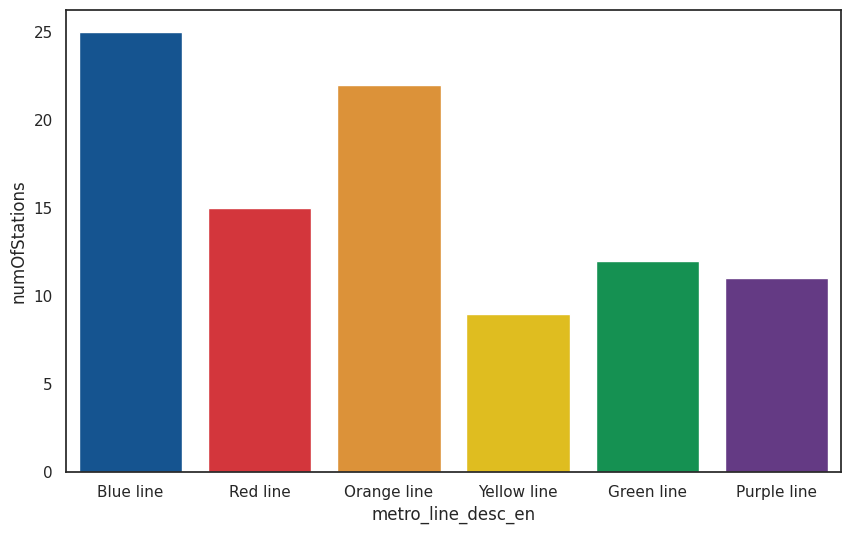

In [129]:
line_colors = {
    'Blue line': '#0055A4',
    'Red line': '#ED1C24',
    'Orange line': '#F7941E',
    'Yellow line': '#FFD200',
    'Green line': '#00A651',
    'Purple line': '#662D91'
}
co = ['0055A4','#ED1C24','#F7941E', '#FFD200','#00A651','#662D91']
plt.figure(figsize=(10, 6))
sns.countplot(data=gdf, x='metro_line_desc_en', hue='metro_line_desc_en', palette=line_colors)
plt.ylabel('numOfStations')
plt.show()

In [130]:
gdf['metro_station_desc_en']

,metro_station_desc_en
0,Dr Sulaiman Al Habib
1,KAFD
2,Al Murooj
3,King Fahad District
4,Al Wurud 2
...,...
89,Airport T1-2
90,King Salman Park
91,Granadia
92,Al Andalus


In [131]:
kafd_stations = gdf[gdf['metro_station_desc_en'] == 'KAFD']
display(kafd_stations)

,index,metro_station_cd,metro_station_desc_en,metro_station_desc_ar,metro_line_cd,metro_line_desc_en,metro_line_desc_ar,metro_station_type_cd,metro_station_type_desc_en,metro_station_type_desc_ar,metro_station_seq,comments_en,comments_ar,geo_point_2d,geometry
1,49,S03,KAFD,المركز المالي,Line1,Blue line,المسار الأزرق,1,Elevated,مرتفع,3,None,None,"{'lon': 46.64364447641301, 'lat': 24.768003925...",POINT (46.64364 24.768)
25,50,S03,KAFD,المركز المالي,Line4,Yellow line,المسار الأصفر,1,Elevated,مرتفع,63,None,None,"{'lon': 46.64360617754577, 'lat': 24.768178633...",POINT (46.64361 24.76818)
29,51,S03,KAFD,المركز المالي,Line6,Purple line,المسار البنفسجي,1,Elevated,مرتفع,84,None,None,"{'lon': 46.64360617754577, 'lat': 24.768178633...",POINT (46.64361 24.76818)


In [141]:
import geopandas as gpd
import pandas as pd
import folium

# 1. Define the Official Riyadh Metro Colors
# This mapping ensures your BI visualization matches reality
line_colors = {
    'Blue line': '#0055A4',
    'Red line': '#ED1C24',
    'Orange line': '#F7941E',
    'Yellow line': '#FFD200',
    'Green line': '#00A651',
    'Purple line': '#662D91'
}

# 2. Initialize the map centered on Riyadh
# 'CartoDB positron' provides a clean, professional background for BI dashboards
m = folium.Map(location=[24.7136, 46.6753], zoom_start=11, tiles='CartoDB positron')

# 3. Add Stations to the Map
for _, row in gdf.iterrows():

    # Get the line name from your data (handle case sensitivity)
    line_name = row['metro_line_desc_en']

    # Select color from dictionary, default to 'gray' if not found
    marker_color = line_colors.get(line_name, 'gray')

    # Add a tiny 'jitter' so overlapping stations stand side-by-side
    lat = row.geometry.y + np.random.uniform(-0.0015, 0.0015)
    lon = row.geometry.x + np.random.uniform(-0.0015, 0.0015)

    # Add a circular marker for each station
    folium.CircleMarker(
        location=[lat, lon],
        radius=6,
        color=marker_color,
        fill=True,
        fill_color=marker_color,
        fill_opacity=0.8,
        # Popups allow users to click and see station details
        popup=folium.Popup(f"""
            <b>Station:</b> {row['metro_station_desc_en']}<br>
            <b>Line:</b> {line_name}<br>
            <b>Type:</b> {row['metro_station_type_desc_en']}
        """, max_width=250)
    ).add_to(m)

# 4. Display the map in your Jupyter Notebook
m

In [133]:
print(gdf['metro_line_desc_en'].value_counts())

metro_line_desc_en
Blue line      25
Orange line    22
Red line       15
Green line     12
Purple line    11
Yellow line     9
Name: count, dtype: int64


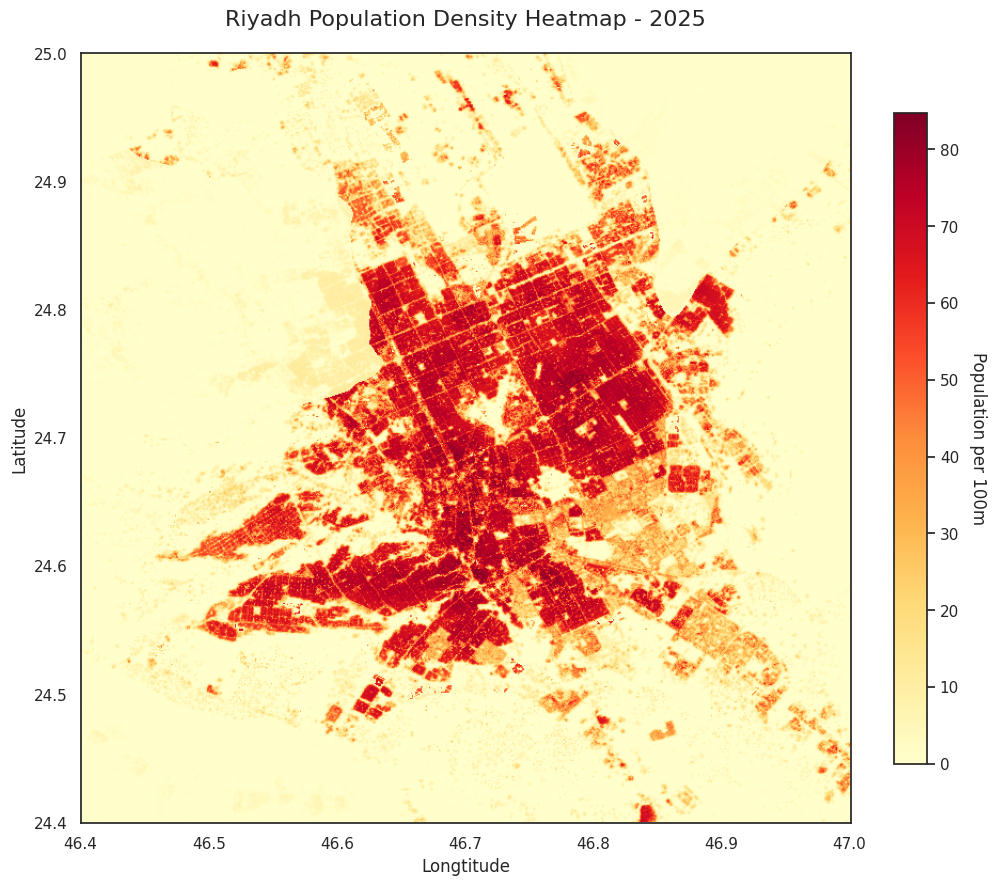

In [134]:
import rasterio
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from rasterio.plot import show

path = '/content/drive/MyDrive/Riyadh-Metro/riyadh_pop_clipped_2025_CN_100m_R2025A_v1.tif'

sns.set_theme(style="white")

with rasterio.open(path) as src:
        data = src.read(1)

        data = np.where(data < 0, 0, data)

        fig, ax = plt.subplots(figsize=(14, 10))

        img = ax.imshow(data, cmap='YlOrRd',
                        extent=[src.bounds.left, src.bounds.right, src.bounds.bottom, src.bounds.top])

        cbar = fig.colorbar(img, ax=ax, fraction=0.03, pad=0.04)
        cbar.set_label('Population per 100m', rotation=270, labelpad=20, fontsize=12)

        plt.title("Riyadh Population Density Heatmap - 2025", fontsize=16, pad=20)
        plt.xlabel("Longtitude")
        plt.ylabel("Latitude")

        plt.show()



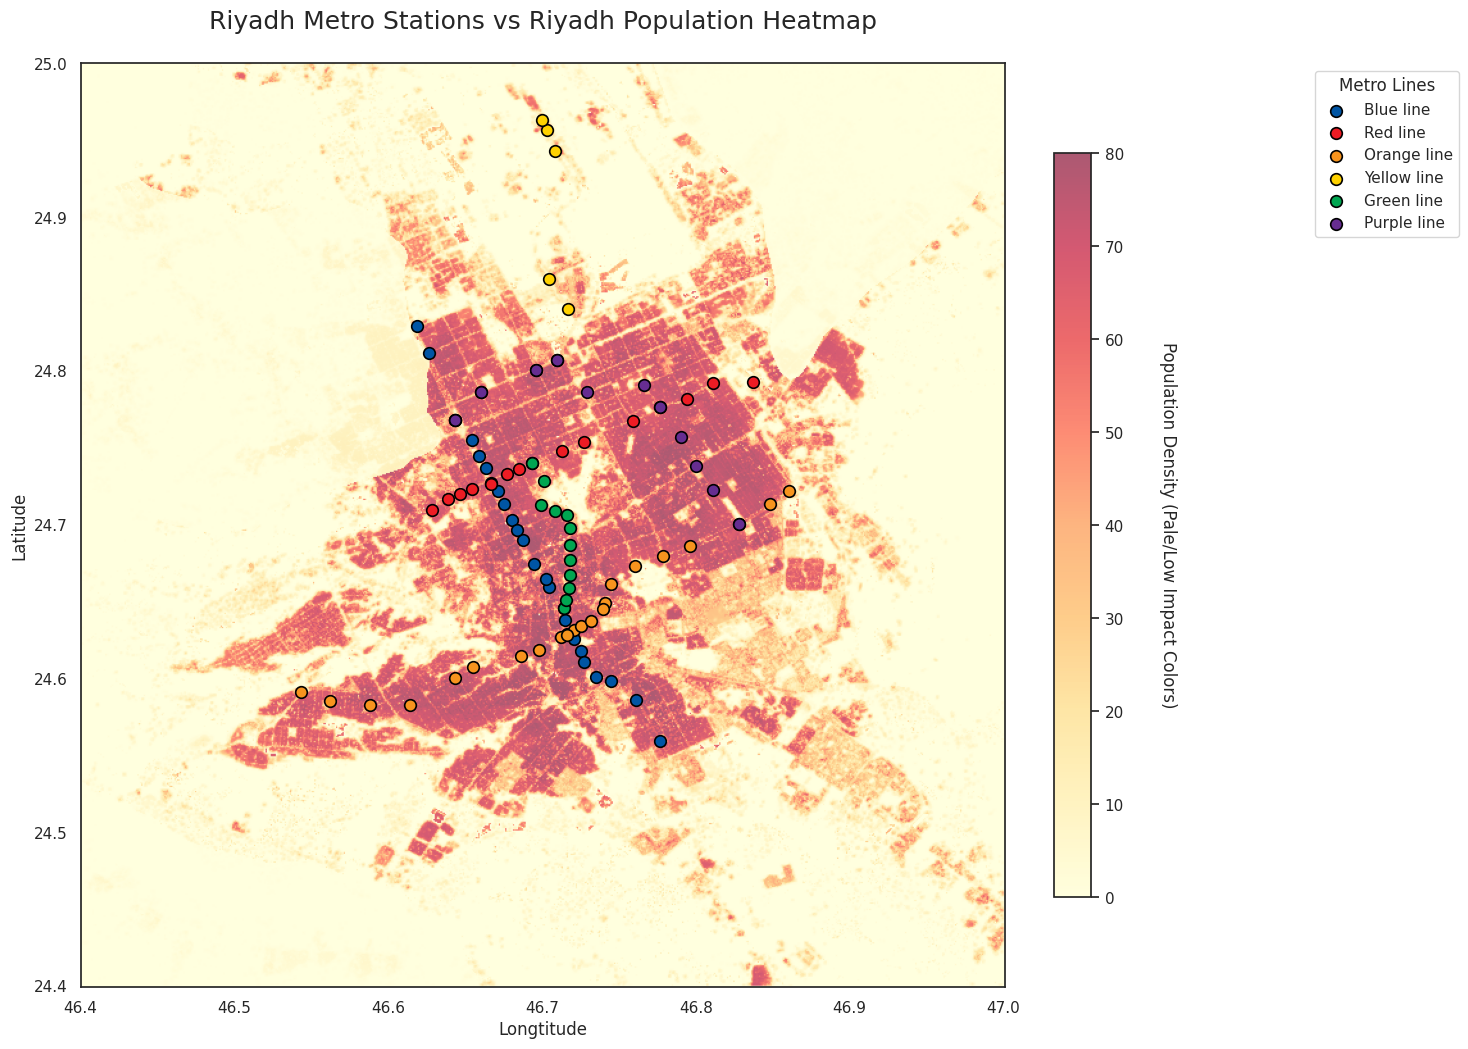

In [135]:
import rasterio
import matplotlib.pyplot as plt
import numpy as np

pop_path = '/content/drive/MyDrive/Riyadh-Metro/riyadh_pop_clipped_2025_CN_100m_R2025A_v1.tif'

with rasterio.open(pop_path) as src:
    pop_data = src.read(1)
    pop_data = np.where(pop_data < 0, 0, pop_data)
    data_clipped = np.where(pop_data > 80, 80, pop_data)

    fig, ax = plt.subplots(figsize=(16, 12))

    img = ax.imshow(data_clipped, cmap='YlOrRd', alpha=0.65,
                    extent=[src.bounds.left, src.bounds.right, src.bounds.bottom, src.bounds.top])

    for line, color in line_colors.items():
        line_data = gdf[gdf['metro_line_desc_en'] == line]

        ax.scatter(line_data.geometry.x, line_data.geometry.y,
                   c=color, s=70, label=line, edgecolors='black', linewidth=1.2, alpha=1.0)

    cbar = fig.colorbar(img, ax=ax, fraction=0.03, pad=0.04)
    cbar.set_label('Population Density (Pale/Low Impact Colors)', rotation=270, labelpad=38)

    ax.legend(title="Metro Lines", loc='upper right', bbox_to_anchor=(1.50, 1))
    plt.title("Riyadh Metro Stations vs Riyadh Population Heatmap", fontsize=18, pad=25)
    plt.xlabel("Longtitude")
    plt.ylabel("Latitude")
    plt.show()